# Read H-Reflex App Data Files

This notebook reads and visualizes data from the **H-Reflex Behavior App** (hreflex_txbdc) binary data files.

**V2 file convention (current):**
- **`.hrs1`** — MH Recruitment Curve stage: sweeps across stimulation intensities to map the M/H-wave recruitment curve.
- **`.hrs2`** — Control Mode stage: stimulates at a fixed user-set intensity (can be changed between trials).
- **`.hrs3`** — Down Condition Pellet (DCP) stage: closed-loop H-reflex conditioning with pellet reward.

**V1 file convention (legacy):**
- **`.hrs1`** — EMG Characterization stage: captures baseline EMG grand-mean distribution.
- **`.hrs2`** — MH Recruitment Curve stage (same binary format as V2 `.hrs1`).

All trial files share the MhRecHeader + MhRecTrial binary format.
EMG data blocks (raw differential, filtered, abs-value) are embedded in every file.

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers + summaries
    read_hrs1, read_hrs2, read_hrs3, find_hrs_files, detect_app_version,
    print_hrs1_summary, print_hrs2_summary,
    # Post-hoc global windowing
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    run_direct_bg_sweep, plot_direct_bg_sweep,
    # M/H response metrics (per-trial normalized)
    compute_mh_metrics, compute_mh_variability_sweep,
    plot_mh_variability, print_mh_variability_summary, view_mh_bin,
    # Section 5 quartile window comparison
    plot_quartile_window_comparison,
    # EMG window optimization
    compute_optimization_scores, plot_optimization, print_optimization_summary,

    plot_amplitude_distribution, plot_background_emg_views,
    plot_actual_trial_timeline,
    simulate_trial_initiation_hrs,
    split_trials_by_polarity, plot_hm_ratio_summary, plot_hwave_regression,

    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: HRS1 File — EMG Characterization (V1 only)

The cells in this section apply only to **V1** recordings where `.hrs1` contains
the EMG Characterization stage. They are automatically skipped for V2 recordings.

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [9]:
recording_dir         = "D3_HRPILOT-17_200US_6-1-26"
recording_sample_rate = None  # Set to e.g. 5000.0 or 10000.0 to override; None = auto-detect from HRS1 header

hrs1_path, hrs2_path, hrs3_path = find_hrs_files(recording_dir)
_app_version = detect_app_version(recording_dir)
print(f"H-Reflex App V{_app_version}  |  "
      f"hrs1={os.path.basename(hrs1_path) if hrs1_path else chr(8211)}  "
      f"hrs2={os.path.basename(hrs2_path) if hrs2_path else chr(8211)}  "
      f"hrs3={os.path.basename(hrs3_path) if hrs3_path else chr(8211)}")


Recording directory: D3_HRPILOT-17_200US_6-1-26
  HRS1 file: D3_HRPILOT-17_200US_6-1-26_20260601T134201.hrs1
  HRS2 file: D3_HRPILOT-17_200US_6-1-26_20260601T135206.hrs2


In [10]:
# --- Load all data files (auto-detects V1 / V2 app) ---------------------------
cm_header  = cm_trials  = cm_emg_blocks  = None   # V2 Control Mode (None in V1)
dcp_header = dcp_trials = dcp_emg_blocks = None   # V2 Down Condition Pellet (None in V1)

if _app_version == 1:
    # V1: S1=EMG Characterization (.hrs1)  S2=MH Recruitment Curve (.hrs2)
    if hrs1_path:
        hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
        print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)
    else:
        print("No .hrs1 file found — EMG Characterization data unavailable.")
        hrs1_header, hrs1_trials, hrs1_emg_blocks = None, [], []
    if hrs2_path:
        hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
        print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)
    else:
        print("No .hrs2 file found — MH Recruitment data unavailable.")
        hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    # V2: S1=MH Recruitment (.hrs1, same binary as V1 .hrs2)
    #     S2=Control Mode (.hrs2)   S3=Down Condition Pellet (.hrs3)
    if hrs1_path:
        hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs1_path)
        hrs1_header = hrs2_header          # alias — no separate EMG char stage in V2
        hrs1_trials, hrs1_emg_blocks = [], []
        print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs1_path)
    else:
        print("No .hrs1 file found — MH Recruitment data unavailable.")
        hrs1_header = hrs2_header = None
        hrs1_trials = hrs2_trials = []
        hrs1_emg_blocks = hrs2_emg_blocks = []
    if hrs2_path:
        cm_header, cm_trials, cm_emg_blocks = read_hrs2(hrs2_path)
        print(f"Control Mode:           {len(cm_trials)} trials")
    else:
        print("No .hrs2 file found — Control Mode data unavailable.")
    if hrs3_path:
        dcp_header, dcp_trials, dcp_emg_blocks = read_hrs3(hrs3_path)
        print(f"Down Condition Pellet:  {len(dcp_trials)} trials")
    else:
        print("No .hrs3 file found — Down Condition Pellet data unavailable.")


# V2 Control Mode-only: no Recruitment Curve stage (.hrs1 absent).
# Alias hrs2_trials <- cm_trials so all downstream analysis cells work unchanged.
if _app_version == 2 and not hrs2_trials and cm_trials:
    hrs2_header     = cm_header
    hrs2_trials     = cm_trials
    hrs2_emg_blocks = cm_emg_blocks
    hrs1_header     = hrs2_header
    print('Note: Control Mode trials used as primary analysis (no Recruitment Curve stage).')

# Ensure hrs1_header.sample_rate is always accessible for downstream cells
if hrs1_header is None:
    class _SampleRateStub:
        sample_rate = recording_sample_rate or 5000.0
    hrs1_header = _SampleRateStub()


=== HRS1 Header ===
  File:               D3_HRPILOT-17_200US_6-1-26_20260601T134201.hrs1
  File version:       1
  Subject ID:         D3_HRPILOT-17_200US_6-1-26
  Session datetime:   2026-06-01 13:42:01.675416
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50
  Sample rate:        15000.0 Hz
  Trials/hr data: centre=105.02 µV, elapsed=0.003 h, 20 window sizes

  Trials found:       3
  EMG data blocks:    752

=== First Trial ===
  End datetime:       2026-06-01 13:42:04.312637
  Start index:        0
  Grand mean:         133.7160
  Bins count:         53
  Monitored signal N: 39750

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:       7 x 192 samples
  Diff samples:       192
  Filtered samples:   192
  Abs samples:        192


# Section 3: Peri-Stimulus Trials — MH Recruitment Curve or Control Mode

For **V2** recordings `hrs2_trials` contains whichever stage was run:
- `.hrs1` present → MH Recruitment Curve trials
- `.hrs1` absent, `.hrs2` present → Control Mode trials (aliased automatically)

For **V1** recordings `hrs2_trials` contains the MH Recruitment Curve trials from `.hrs2`.

In [11]:
# Data already loaded in the cell above.
# hrs2_trials = MH Recruitment Curve trials (V1 or V2).
print(f"MH Recruitment trials : {len(hrs2_trials)}"
      + (f"  |  Control Mode: {len(cm_trials)}" if cm_trials  is not None else "")
      + (f"  |  DCP: {len(dcp_trials)}"         if dcp_trials is not None else ""))


=== HRS2 Header ===
  File:               D3_HRPILOT-17_200US_6-1-26_20260601T135206.hrs2
  File version:       7  (v7: + digital_onset_sample_num/channel)
  Subject ID:         D3_HRPILOT-17_200US_6-1-26
  Session start time: 2026-06-01 13:52:06.311917
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       1225
  EMG data blocks:    385301
  Stim polarity:      765 normal, 460 reversed  <-- dual-polarity session
  Digital onsets:     0/1225 trials have digital onset  <-- none detected

=== First EMG Block ===
  Channel names:  ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:   7 x 191 samples
  Diff samples:   191


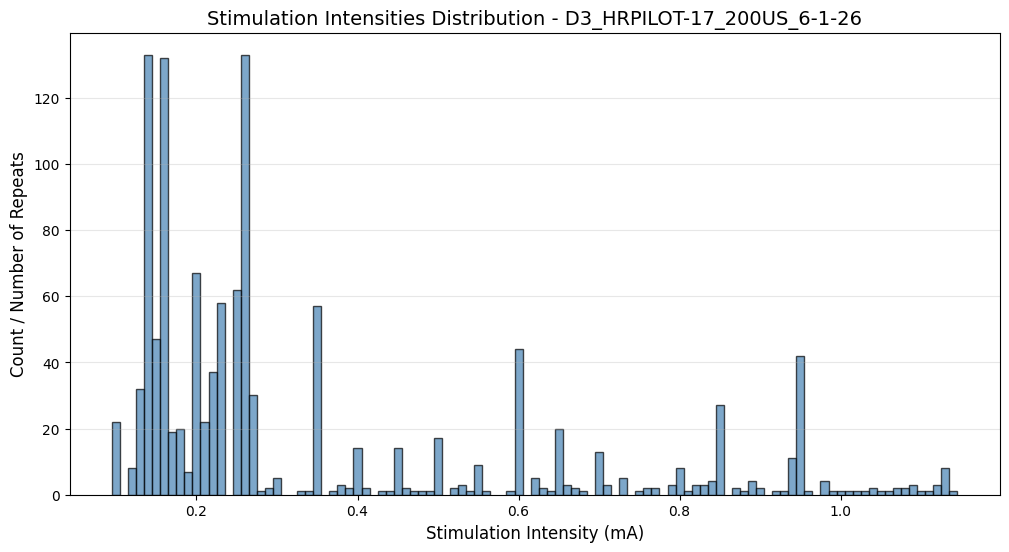

1225 trials used stored bins  |  0 trials reconstructed from emg_blocks.


In [12]:
# ---- Histogram of stimulation intensities ----
plot_amplitude_distribution(hrs2_trials, hrs2_header)

# ---- "Most recent background" + "Background EMG Level" plots ----
# Mirrors the H-Reflex App recruitment-curve trial plot widgets.
# Uses stored background_bins / background_emg_mean from each trial (file_version >= 5);
# falls back to reconstructing from emg_blocks for older files.
plot_background_emg_views(hrs2_trials, hrs2_emg_blocks, monitoring_window_ms=2500,
                          sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                          bin_duration_ms=hrs1_header.bin_duration_ms)

Actual trial timeline (1225 trials)
  Recording span : 12018.5 s  (3.338 h)
  Trial rate     : 366.9 trials / hour
  ITI — mean: 9819 ms  |  median: 5447 ms  |  min: 2747 ms  |  max: 2523185 ms


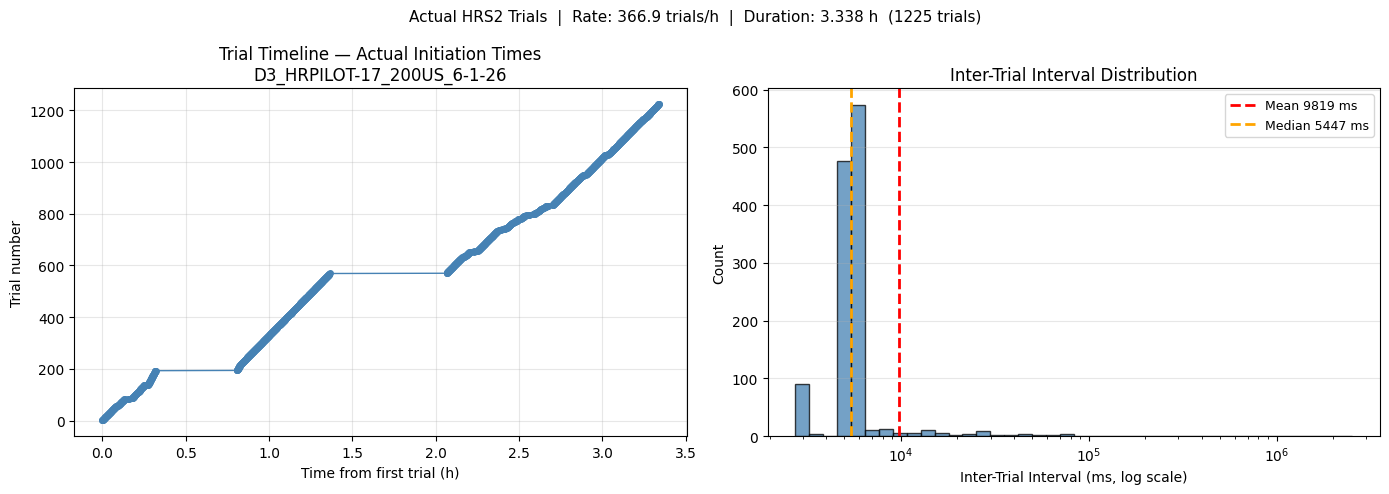

In [13]:
# ---- Actual trial timeline + ITI distribution + trial rate ----
plot_actual_trial_timeline(hrs2_trials, header=hrs2_header)

# Section 4: Post-Hoc Background EMG Analysis

Reconstruct the continuous abs-EMG signal from HRS2 EMG blocks, blank around each stimulation event, compute background statistics, extract per-trial pre-stim grand means, and run the direct background sweep.

**Steps:**
1. **4a** — Sort and stitch all HRS2 EMG blocks into one continuous signal.
2. **4b** — Build a blank mask that suppresses samples within ±[`blank_pre_ms`, `blank_post_ms`] of every stimulation event.
3. **4c** — Compute global background EMG statistics from the non-blanked signal.
4. **4d** — Extract each trial's pre-stim background grand mean and plot the distribution.
5. **4e** — Run the direct per-trial background sweep (EMG window width vs matched trials).

In [14]:
# ---- Section 4: Post-hoc background EMG analysis ----
state = analyze_global_background(
    hrs2_trials, hrs2_emg_blocks, hrs2_header,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    blank_pre_ms=5, blank_post_ms=20,
    min_valid_frac=0.7,
)

Section 4a: Reconstructing continuous signal from HRS2 EMG blocks
  Blocks stitched : 385,301
  Total samples   : 12,030,687
  Duration        : 802.0 s  (13.4 min)
  OE sample range : 1780339926161 – 1780351956848
  Gap samples     : 6,949,880  (57.768% of total)

Section 4b: Building blank mask around stimulation events
Blank mask: 0 events -> 0 samples blanked (0.0000 fraction)
  Stim events mapped  : 0 of 1225
  Unmapped (no onset) : 1225
  Non-blanked samples : 12,030,687  (100.0%)

Section 4c: Background EMG statistics (non-blanked samples)
  n       : 12,030,687
  Mean    : 40.764 µV
  Std     : 116.141 µV
  Q1      : 0.000 µV
  Median  : 0.000 µV
  Q3      : 33.146 µV

Section 4d: Per-trial pre-stim background grand means


IndexError: index -1 is out of bounds for axis 0 with size 0

# Section 4b: Virtual Trial Rate Sweep

Walks the continuous background EMG signal (with stim periods blanked) using the
same state machine as the H-Reflex app: random monitoring windows 2200–2700 ms,
50 ms bins, accepts when all bin grand means fall within the threshold window.

**Output**: virtual trial rate (trials/hour) vs EMG window half-width,
evaluated at Q1, Median, and Q3 of the background distribution.

This is the primary sweep used by the **Section 7 Optimization**.

Section 4b: Running post-hoc virtual trial rate sweep
Signal duration : 1331.5 s | Non-blanked: 100.0%
Background stats: mean=324.35  Q1=379.44  Med=414.19  Q3=444.84 µV



  Q1     (centre=379.44 µV):  ±5→424.5/hr  ±10→454.2/hr  ±20→494.8/hr  ±30→540.7/hr  ±45→627.3/hr  ±60→738.1/hr  ±75→843.6/hr  ±100→1049.0/hr  ±125→1305.9/hr  ±150→1441.1/hr
  Median (centre=414.19 µV):  ±5→324.4/hr  ±10→362.3/hr  ±20→402.9/hr  ±30→467.7/hr  ±45→548.9/hr  ±60→605.6/hr  ±75→681.3/hr  ±100→835.4/hr  ±125→1016.6/hr  ±150→1230.2/hr
  Q3     (centre=444.84 µV):  ±5→221.7/hr  ±10→267.7/hr  ±20→300.1/hr  ±30→354.2/hr  ±45→419.1/hr  ±60→505.6/hr  ±75→584.0/hr  ±100→681.3/hr  ±125→827.3/hr  ±150→957.1/hr


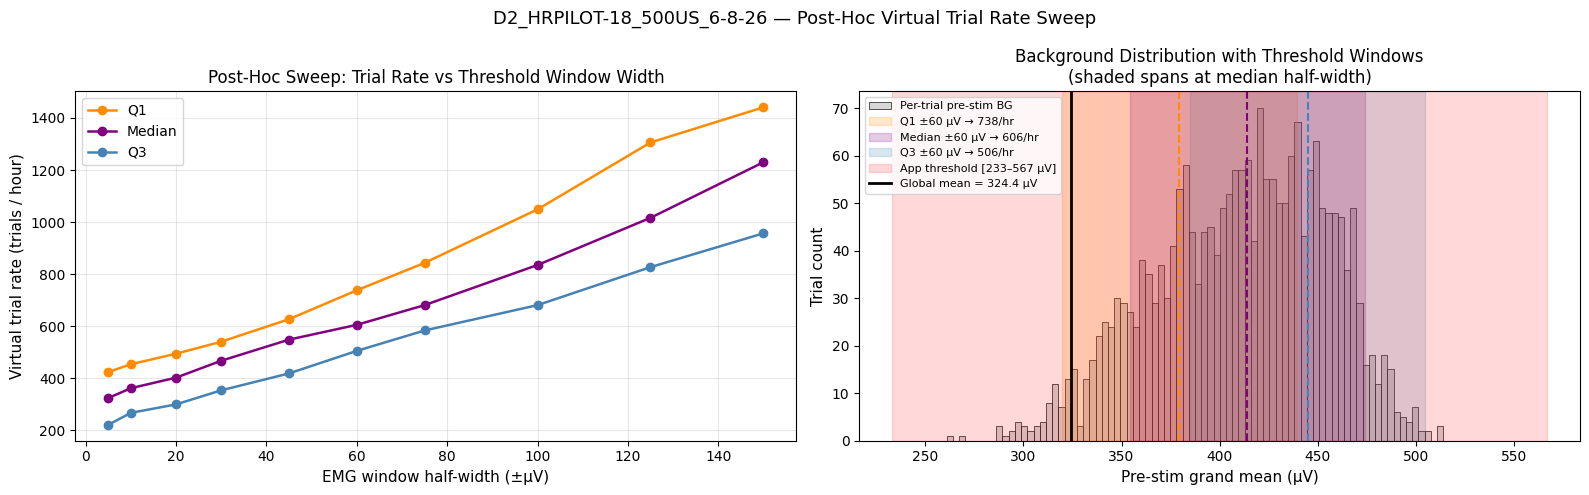


Session duration: 1332 s  (0.370 h)
Global EMG grand mean = 324.353 µV  (std=410.885, Q1=11.285, median=176.054, Q3=485.690)

    Centre   ±hw (µV)   Min (µV)   Max (µV)   Accepted    Trials/hr
-------------------------------------------------------------------
        Q1          5     374.44     384.44        157        424.5
        Q1         10     369.44     389.44        168        454.2
        Q1         20     359.44     399.44        183        494.8
        Q1         30     349.44     409.44        200        540.7
        Q1         45     334.44     424.44        232        627.3
        Q1         60     319.44     439.44        273        738.1
        Q1         75     304.44     454.44        312        843.6
        Q1        100     279.44     479.44        388       1049.0
        Q1        125     254.44     504.44        483       1305.9
        Q1        150     229.44     529.44        533       1441.1

    Median          5     409.19     419.19        120  

In [ ]:
# ---- Section 4b: Virtual trial rate sweep ----
# sweep_centres and half_widths_uv are reused by the M-H variability sweep
# in Section 6a -- keep them consistent for Section 7 optimization.
sweep_centres  = {'Q1': state['gm_q1'], 'Median': state['gm_med'], 'Q3': state['gm_q3']}
half_widths_uv = [5, 10, 20, 30, 45, 60, 75, 100, 125, 150]

sweep_results = run_threshold_sweep(
    state, sweep_centres=sweep_centres, half_widths_uv=half_widths_uv,
)
plot_threshold_sweep(sweep_results, state, hrs2_trials, hrs2_header)

# Section 4c: Direct Background Trial Count (Reference)

Retrospective count: of the **actual HRS2 trials recorded**, how many had a
pre-stimulus background grand mean within each threshold window?

> **Note**: this does *not* simulate trial rate — it only counts trials that
> *were already collected* whose background happened to be in-window.
> For prospective trial rate estimation, see Section 4b above.

Section 5a: Direct per-trial background sweep
  Background window → 1 µV bins → mean per bin → grand mean
  Actual HRS2 trials : 2119
  Background Q1=379.44  Median=414.19  Q3=444.84 µV

  Q1     (centre=379.44 µV):  ±5→157  ±10→273  ±20→513  ±30→759  ±50→1244  ±75→1741  ±100→2043  ±150→2119
  Median (centre=414.19 µV):  ±5→174  ±10→357  ±20→661  ±30→968  ±50→1554  ±75→1962  ±100→2089  ±150→2118
  Q3     (centre=444.84 µV):  ±5→176  ±10→356  ±20→665  ±30→950  ±50→1347  ±75→1710  ±100→1950  ±150→2111

    Centre   ±hw (µV)   Min (µV)   Max (µV)    Matched   Fraction  BG Grand Mean
--------------------------------------------------------------------------------
        Q1          5     374.44     384.44        157      7.4%         379.43
        Q1         10     369.44     389.44        273     12.9%         379.42
        Q1         20     359.44     399.44        513     24.2%         379.43
        Q1         30     349.44     409.44        759     35.8%         379.43
        Q1  

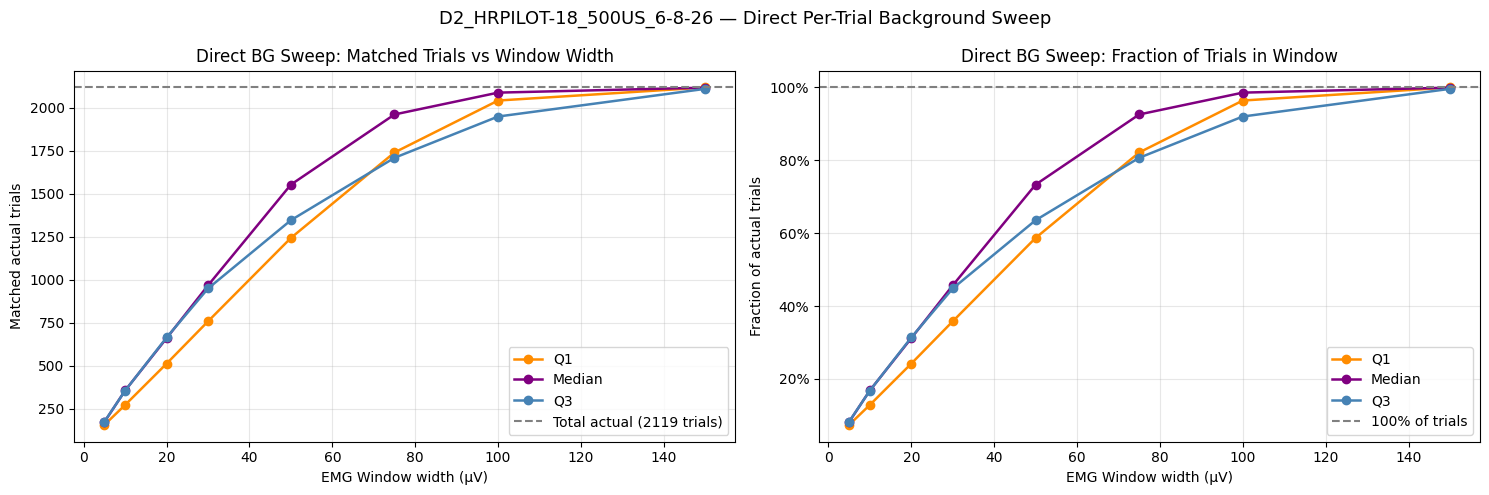

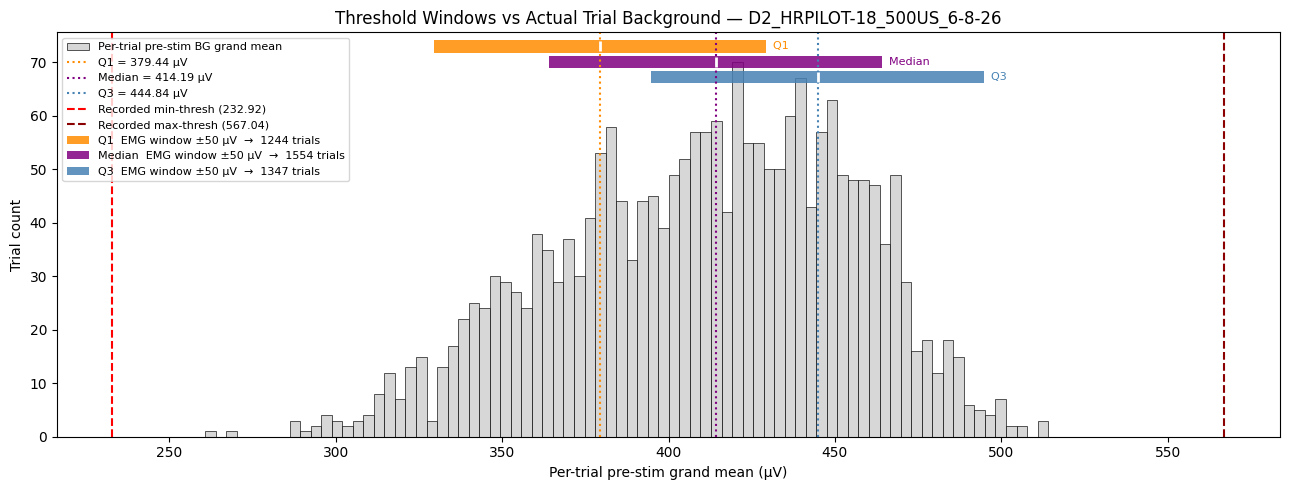

In [ ]:
# ---- Section 4c: Direct background trial count (retrospective reference) ----
direct_bg_results = run_direct_bg_sweep(state)
plot_direct_bg_sweep(direct_bg_results, state, hrs2_trials, hrs2_header)

# Section 4d: Trial Initiation Simulator

Re-runs the H-Reflex app's trial-initiation state machine on the recorded EMG signal.

- **HRS1 source**: uses background EMG blocks from the EMG Characterization stage (no stim blanking).
- **HRS2 source**: uses peri-stim EMG blocks from the Recruitment Curve stage; samples around each stim onset are zeroed so stim artifacts cannot trigger initiation.

Set `SIM_SOURCE`, `SIM_MIN_UV`, `SIM_MAX_UV`, and `SIM_MIN_ITI_MS` in the cell below, then run it.

In [ ]:
# ---- Section 4d: Trial Initiation Simulation ----
#
# SIM_SOURCE: which EMG blocks to use
#   "hrs1" -- background EMG from the EMG Characterization stage (no stim blanking)
#   "hrs2" -- peri-stim EMG from the Recruitment Curve stage (stim periods zeroed)
SIM_SOURCE      = "hrs1"   # "hrs1" or "hrs2"

# Initiation thresholds (µV). Set to None to read from hrs1_header.
SIM_MIN_UV      = None     # e.g. 50.0  or None
SIM_MAX_UV      = None     # e.g. 200.0 or None

# Minimum inter-trial interval (ms)
SIM_MIN_ITI_MS  = 3000

# Stim blanking window used in HRS2 mode
SIM_BLANK_PRE_MS  = 5.0
SIM_BLANK_POST_MS = 20.0

_emg_blocks = hrs1_emg_blocks if SIM_SOURCE == "hrs1" else hrs2_emg_blocks
_sim_header = hrs1_header     if SIM_SOURCE == "hrs1" else hrs2_header
_trials_for_blank = None      if SIM_SOURCE == "hrs1" else hrs2_trials

# Default thresholds come from the HRS1 file header (what the app actually used)
_sim_min = SIM_MIN_UV if SIM_MIN_UV is not None else float(hrs1_header.trial_initiation_uv_min)
_sim_max = SIM_MAX_UV if SIM_MAX_UV is not None else float(hrs1_header.trial_initiation_uv_max)

simulated_trials, sim_statistics = simulate_trial_initiation_hrs(
    _emg_blocks,
    _sim_header,
    hrs2_trials=_trials_for_blank,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    min_init_uv=_sim_min,
    max_init_uv=_sim_max,
    min_inter_trial_ms=SIM_MIN_ITI_MS,
    blank_pre_ms=SIM_BLANK_PRE_MS,
    blank_post_ms=SIM_BLANK_POST_MS,
)

Trial Initiation Simulator — HRS1 source | D2_HRPILOT-18_500US_6-8-26
  Blocks stitched : 2,358
  Total samples   : 23,252  (1.6 s / 0.0 min)
  Sample rate     : 15000 Hz
  Thresholds      : 15.0 – 300.0 µV
  Min ITI         : 3000 ms

STARTING TRIAL INITIATION SIMULATION (with bin sliding)
Total samples: 23,252 | Duration: 1.55s
Thresholds: 15.0 - 300.0 uV
Min ITI: 3000 ms | Block: 50 samples | Bin slide: 50 ms (750 samples)

[NOT_SETUP -> WAIT] Attempt #1 | Window: 2550 ms | Time: 0.00s
[10%] Attempts:1 | Trials:0 (immediate:0 shifted:0) | GM:14.36 uV | 0.0s
[20%] Attempts:1 | Trials:0 (immediate:0 shifted:0) | GM:28.39 uV | 0.0s
[30%] Attempts:1 | Trials:0 (immediate:0 shifted:0) | GM:43.21 uV | 0.0s
[40%] Attempts:1 | Trials:0 (immediate:0 shifted:0) | GM:54.02 uV | 0.0s
[50%] Attempts:1 | Trials:0 (immediate:0 shifted:0) | GM:66.55 uV | 0.1s
[60%] Attempts:1 | Trials:0 (immediate:0 shifted:0) | GM:81.26 uV | 0.1s
[70%] Attempts:1 | Trials:0 (immediate:0 shifted:0) | GM:93.70 uV | 

# Section 5: Quartile Window Comparison

For a fixed **EMG window width** (±`hw_uv` µV), compare the trials selected by windows
centred on **Q1**, **Median**, and **Q3** of the background distribution.

- **Plot 1** — histogram of per-trial background with shaded EMG windows for each quartile.
- **Interactive viewer** — dropdown selects Q1 / Median / Q3 / All:
  - *Left*: peri-stimulus waveforms (−2 ms to 15 ms), M/H window shading,
    group avg (black) + SEM, overall recording avg (blue).
  - *Right*: 2500 ms pre-stimulus background, same group vs overall overlays.

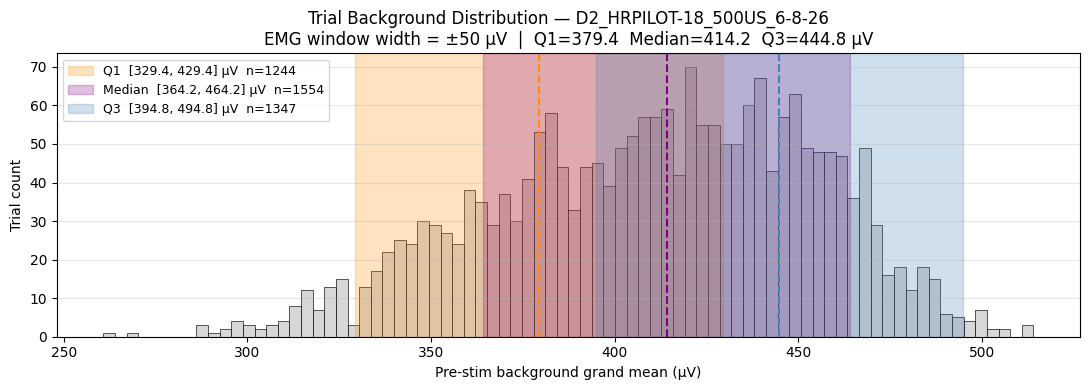

Pre-computing 2500 ms background bins for 2119 trials… done.
Pre-computing overall averages… done  (2119 peri-stim trials).


In [ ]:
# ---- Section 5: Quartile window comparison (fixed EMG window width) ----
M_START_MS_S5, M_END_MS_S5 = 2.5, 5.5
H_START_MS_S5, H_END_MS_S5 = 7, 11.5

plot_quartile_window_comparison(
    hrs2_trials, hrs2_emg_blocks, state, hrs2_header,
    hw_uv=50,
    pre_ms=2.0, post_ms=15.0,
    bg_pre_ms=2500.0,
    m_start_ms=M_START_MS_S5, m_end_ms=M_END_MS_S5,
    h_start_ms=H_START_MS_S5, h_end_ms=H_END_MS_S5,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 6: M-/H-Response Variability vs EMG Window Size

For every trial we measure three response metrics inside the M and H windows,
each normalised to that trial's own pre-stim background grand mean:

- **M-H Peak (MRA)** — `mean(|emg|)` in the M or H window  (µV)
- **H/M Ratio** — `H-MRA / M-MRA` per trial
- **M-H Size** — `(MRA − per_trial_bg) / per_trial_bg`  (units of background activity)

For centres at **Q1 / Median / Q3** of the background distribution we sweep a
EMG window width `hw`, group trials whose background falls in `[centre ± hw]`, and
compute STD and CV (Coefficient of Variation = STD / Mean) for all metrics.

Output:
1. A 3 × 2 figure — STD (left) and CV (right) for M-H Peak, H/M Ratio, M-H Size.
2. A summary table at the 10 marker EMG window widths.
3. An interactive bin viewer.

In [ ]:
# ---- Section 6a: Per-trial M-H metrics (per-trial background normalization) ----
M_START_MS, M_END_MS = 3.0, 5.5
H_START_MS, H_END_MS = 6.5, 11.5

mh_metrics = compute_mh_metrics(
    hrs2_trials, state['trial_bg_gm'],
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

sweep_centres  = {'Q1': state['gm_q1'], 'Median': state['gm_med'], 'Q3': state['gm_q3']}
half_widths_uv = [5, 10, 20, 30, 45, 60, 75, 100, 125, 150]

mh_variability = compute_mh_variability_sweep(
    state['trial_bg_gm'], mh_metrics, sweep_centres, half_widths_uv,
)

n = len(hrs2_trials)
print(f"Computed M-H metrics for {n} trials (per-trial background normalization)")
print(f"M window: {M_START_MS}–{M_END_MS} ms  |  H window: {H_START_MS}–{H_END_MS} ms")
print()
for key, label in [('m_mra',    'M-MRA (µV)     '),
                   ('h_mra',    'H-MRA (µV)     '),
                   ('hm_ratio', 'H/M ratio       '),
                   ('m_size',   'M-size (×bg)   '),
                   ('h_size',   'H-size (×bg)   ')]:
    arr = mh_metrics[key]
    v = arr[~np.isnan(arr)]
    if len(v) == 0:
        print(f"  {label}: no valid data")
        continue
    print(f"  {label}  n={len(v)}  mean={np.mean(v):.4f}  "
          f"std={np.std(v, ddof=1):.4f}  median={np.median(v):.4f}  "
          f"min={np.min(v):.4f}  max={np.max(v):.4f}")


Computed M-H metrics for 2119 trials (per-trial background normalization)
M window: 3.0–5.5 ms  |  H window: 6.5–11.5 ms

  M-MRA (µV)       n=2119  mean=327.3025  std=240.3139  median=265.8457  min=10.0296  max=2555.3901
  H-MRA (µV)       n=2119  mean=832.9135  std=526.0719  median=688.9390  min=19.2785  max=3233.1052
  H/M ratio         n=2119  mean=4.0252  std=4.3979  median=2.6668  min=0.0583  max=37.3388
  M-size (×bg)     n=2119  mean=-0.1974  std=0.5949  median=-0.3450  min=-0.9757  max=4.6566
  H-size (×bg)     n=2119  mean=1.0469  std=1.3031  median=0.7257  min=-0.9523  max=6.7464


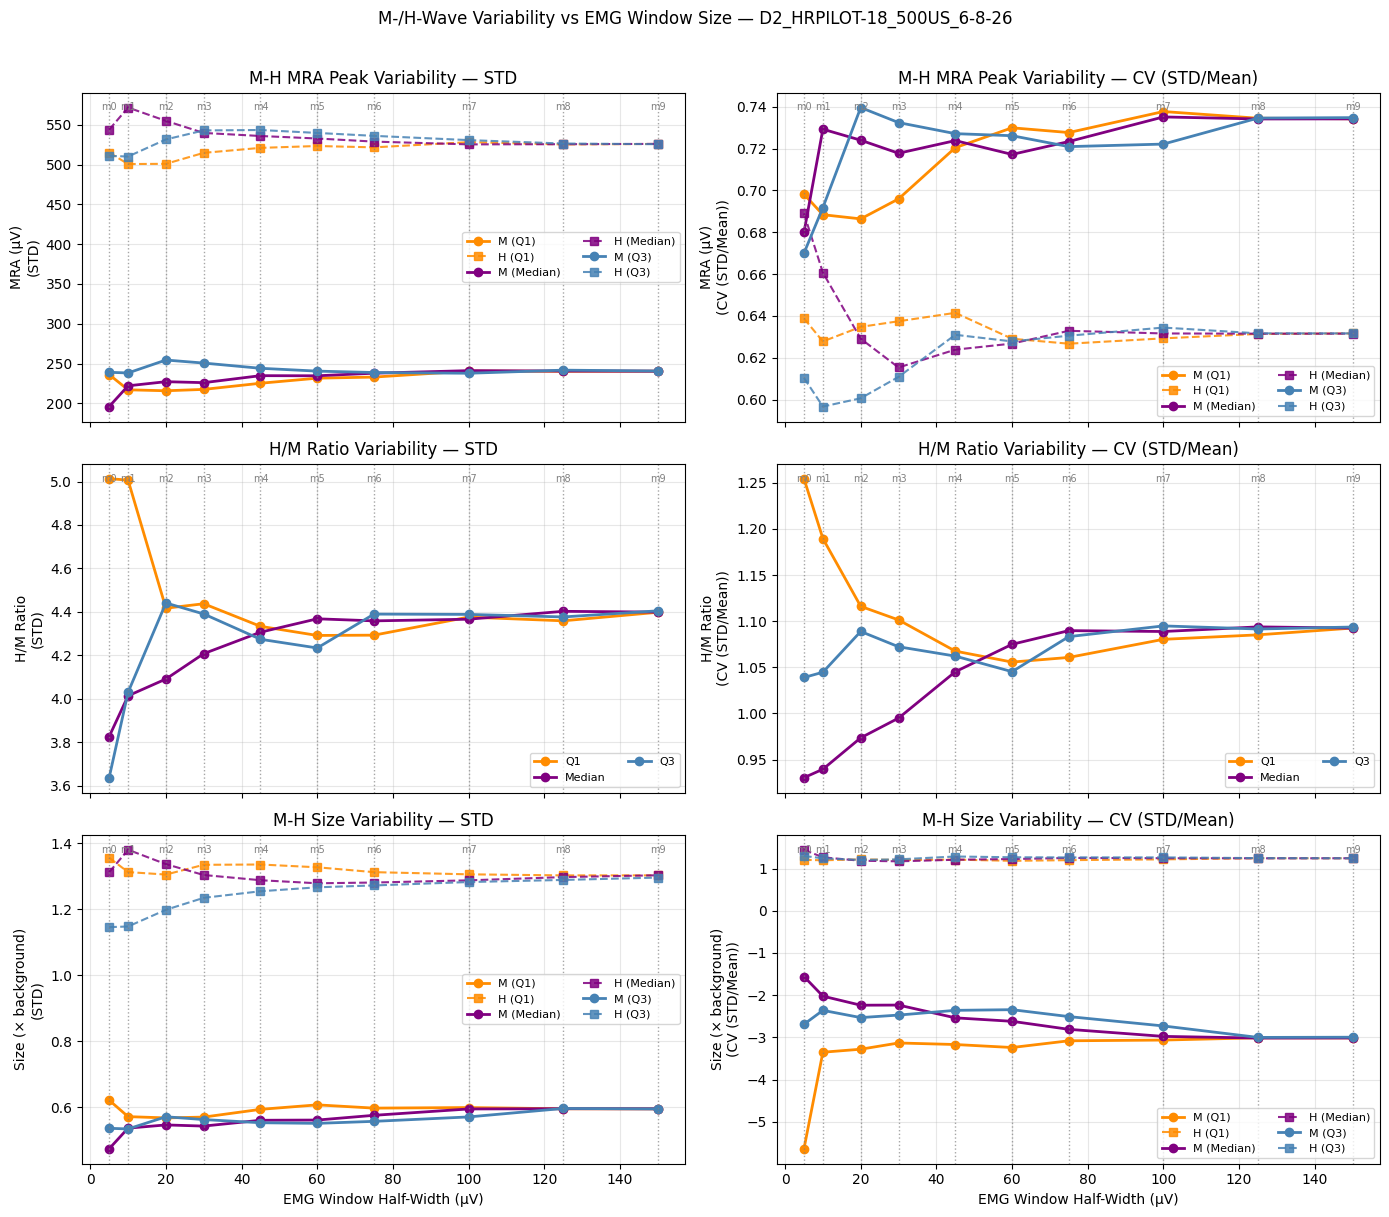

Marker EMG window widths: ['5.0', '10.0', '20.0', '30.0', '45.0', '60.0', '75.0', '100.0', '125.0', '150.0']


In [ ]:
# ---- Section 6b: Variability plot (3 rows x 2 cols: STD / CV) ----
marker_hws = plot_mh_variability(mh_variability, hrs2_header, marker_hws=half_widths_uv)
print(f"Marker EMG window widths: {[f'{hw:.1f}' for hw in marker_hws]}")

In [ ]:
# ---- Section 6c: Summary table at the 10 marker EMG window widths ----
mh_at_markers = compute_mh_variability_sweep(
    state['trial_bg_gm'], mh_metrics, sweep_centres,
    half_widths_uv=marker_hws,
)
print_mh_variability_summary(mh_at_markers, sweep_centres, hrs2_header,
                              marker_hws=marker_hws)


=== D2_HRPILOT-18_500US_6-8-26 — M-H variability summary ===
    Centre   ±hw (µV)      n   M-MRA STD   H-MRA STD   H/M STD   M-sz STD   H-sz STD   M-MRA CV   H-MRA CV   H/M CV
-------------------------------------------------------------------------------------------------------------------
        Q1        5.0    157     236.045     515.248     5.013      0.621      1.357      0.698      0.639    1.255
        Q1       10.0    273     216.942     500.787     5.007      0.571      1.313      0.688      0.628    1.190
        Q1       20.0    513     215.718     501.060     4.417      0.567      1.306      0.686      0.635    1.116
        Q1       30.0    759     217.444     514.867     4.437      0.570      1.335      0.696      0.637    1.101
        Q1       45.0   1146     225.179     521.110     4.333      0.593      1.336      0.720      0.641    1.068
        Q1       60.0   1452     231.568     523.465     4.291      0.607      1.328      0.730      0.629    1.056
        Q1

# Section 6d: Manual EMG Activity Bins

Classify trials into user-defined pre-stim EMG level bins using the per-trial grand means from Section 4 (`state['trial_bg_gm']`).

Edit the `BIN_LO_x / BIN_HI_x` pairs below to set your own µV ranges.
Trials whose background grand mean falls within `[lo, hi)` are grouped into that bin.

**Outputs:**
- **6d-bins** — bin definition + trial count summary
- **6d-overview** — averaged waveform overlay + M / H / H:M bar charts + stats panel per polarity


In [ ]:
# ---- Section 6d-bins: Define EMG Activity Bins ----
BIN_LO_1, BIN_HI_1 =  50, 150   # µV  Bin 1
BIN_LO_2, BIN_HI_2 = 150, 200   # µV  Bin 2
BIN_LO_3, BIN_HI_3 = 200, 350   # µV  Bin 3

_EMG_BINS   = [(BIN_LO_1, BIN_HI_1), (BIN_LO_2, BIN_HI_2), (BIN_LO_3, BIN_HI_3)]
_BIN_LABELS = [f'Bin {i+1}: {lo}–{hi} µV' for i, (lo, hi) in enumerate(_EMG_BINS)]
_BIN_COLORS = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'mediumpurple'][:len(_EMG_BINS)]

_bg_gm    = state['trial_bg_gm']
_by_pol   = split_trials_by_polarity(hrs2_trials)
_pol_lbls = list(_by_pol.keys())
_id_map   = {id(t): i for i, t in enumerate(hrs2_trials)}

_binned = {
    pol: {
        lbl: [t for t in trs if lo <= _bg_gm[_id_map[id(t)]] < hi]
        for lbl, (lo, hi) in zip(_BIN_LABELS, _EMG_BINS)
    }
    for pol, trs in _by_pol.items()
}

_hdr = f"{'Bin':<25}  " + "  ".join(f"{p:<12}" for p in _pol_lbls)
print(_hdr)
print("-" * len(_hdr))
for lbl in _BIN_LABELS:
    _row = "  ".join(f"{len(_binned[p][lbl]):<12}" for p in _pol_lbls)
    print(f"{lbl:<25}  {_row}")


Dual-polarity session detected: 1081 normal, 1038 reversed → analysing separately.
Bin                        Normal (0)    Reversed (1)
-----------------------------------------------------
Bin 1: 50–150 µV           0             0           
Bin 2: 150–200 µV          0             0           
Bin 3: 200–350 µV          105           111         


In [ ]:
# ---- Section 6d-overview: Combined EMG Bin Overview ----
# Averaged waveforms + M / H / H:M bar charts (MRA, mean ± STD) + stats panel.
# Polarity toggle when both polarities are present.
from helpers import get_trial_window as _gtw
from ipywidgets import ToggleButtons as _TB6, Output as _Out6, VBox as _VB6
from IPython.display import display as _disp6

_sr6  = recording_sample_rate or hrs1_header.sample_rate
_ms6  = 1000.0 / _sr6
_pre6, _post6 = 2.0, 15.0   # ms window around stim onset for averaged view
_out6 = _Out6()

def _draw_overview6(pol_lbl):
    _bins = _binned[pol_lbl]
    with _out6:
        _out6.clear_output(wait=True)

        _avgs, _m_mra, _h_mra, _hm_mra, _ns = {}, {}, {}, {}, {}
        for lbl in _BIN_LABELS:
            trs = _bins[lbl]
            _ns[lbl] = len(trs)
            if not trs:
                _avgs[lbl] = None
                _m_mra[lbl] = _h_mra[lbl] = _hm_mra[lbl] = []
                continue
            stacks, mv_l, hv_l, hm_l = [], [], [], []
            t_ref = None
            for tr in trs:
                _tm, _emg, _, _, _ = _gtw(tr, _pre6, _post6, ms_per_sample=_ms6)
                if t_ref is None:
                    t_ref = _tm
                stacks.append(_emg[:len(t_ref)])
                _mm = (_tm >= M_START_MS) & (_tm <= M_END_MS)
                _hm = (_tm >= H_START_MS) & (_tm <= H_END_MS)
                if _mm.any():
                    mv_l.append(float(np.nanmean(np.abs(_emg[_mm]))))
                if _hm.any():
                    hv_l.append(float(np.nanmean(np.abs(_emg[_hm]))))
                if _mm.any() and _hm.any():
                    mv = float(np.nanmean(np.abs(_emg[_mm])))
                    hv = float(np.nanmean(np.abs(_emg[_hm])))
                    if mv > 0:
                        hm_l.append(hv / mv)
            _avgs[lbl]  = (t_ref, np.nanmean(np.vstack(stacks), axis=0)) if stacks else None
            _m_mra[lbl] = mv_l
            _h_mra[lbl] = hv_l
            _hm_mra[lbl] = hm_l

        present = [b for b in _BIN_LABELS if _ns[b] > 0]
        cols    = [_BIN_COLORS[_BIN_LABELS.index(b)] for b in present]
        x_pos   = np.arange(len(present))

        fig, axes = plt.subplots(1, 5, figsize=(22, 5),
                                 gridspec_kw={'width_ratios': [5, 3, 3, 3, 2.5]})
        ax_w, ax_m, ax_h, ax_hm, ax_txt = axes

        for lbl, col in zip(present, cols):
            if _avgs[lbl] is not None:
                t_r, avg = _avgs[lbl]
                ax_w.plot(t_r, avg, color=col, linewidth=2.2,
                          label=f'{lbl}  (n={_ns[lbl]})')
        ax_w.axvspan(M_START_MS, M_END_MS, color='blue',  alpha=0.12, zorder=0)
        ax_w.axvspan(H_START_MS, H_END_MS, color='green', alpha=0.12, zorder=0)
        ax_w.axvline(0, color='red', linestyle='--', linewidth=1.0, label='Stim onset')
        ax_w.set_xlabel('Time re: stim onset (ms)')
        ax_w.set_ylabel('EMG (µV)')
        ax_w.set_title(f'Avg Waveforms — {pol_lbl}')
        ax_w.legend(fontsize=8, loc='upper right')
        ax_w.grid(True, alpha=0.3)

        def _bar6(ax, vd, ylabel, title):
            for xi, (lbl, col) in enumerate(zip(present, cols)):
                v = np.array([x for x in vd[lbl] if np.isfinite(x)])
                mu = float(np.mean(v)) if len(v) else 0.0
                sd = float(np.std(v, ddof=1)) if len(v) > 1 else 0.0
                ax.bar(xi, mu, color=col, alpha=0.78, yerr=sd, capsize=6,
                       error_kw={'elinewidth': 2, 'ecolor': col, 'capthick': 2})
            ax.set_xticks(x_pos)
            ax.set_xticklabels(present, rotation=20, ha='right', fontsize=7)
            ax.set_ylabel(ylabel, fontsize=9)
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.grid(True, axis='y', alpha=0.3)

        _bar6(ax_m,  _m_mra,  'MRA (µV)', 'M-wave')
        _bar6(ax_h,  _h_mra,  'MRA (µV)', 'H-wave')
        _bar6(ax_hm, _hm_mra, 'H:M',      'H:M Ratio')

        ax_txt.axis('off')
        lines = [f'Stats — {pol_lbl}', '']
        for lbl in present:
            lines.append(lbl)
            for key, vd in [('M', _m_mra), ('H', _h_mra), ('H:M', _hm_mra)]:
                v = np.array([x for x in vd[lbl] if np.isfinite(x)])
                if len(v):
                    mu = float(np.mean(v))
                    sd = float(np.std(v, ddof=1)) if len(v) > 1 else 0.0
                    cv = sd / mu if mu != 0 else float('nan')
                    lines.append(f'  {key}: n={len(v)} SD={sd:.2f} CV={cv:.2f}')
            lines.append('')
        ax_txt.text(0.05, 0.97, '\n'.join(lines), transform=ax_txt.transAxes,
                    va='top', ha='left', fontsize=7.5, family='monospace',
                    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#cccccc'))

        plt.suptitle(f'Combined EMG Bin Overview  —  {hrs2_header.subject_id}', fontsize=11)
        plt.tight_layout()
        plt.show()

if len(_pol_lbls) > 1:
    _tgl6 = _TB6(options=_pol_lbls, button_style='info', description='Polarity:')
    def _on_pol6(change):
        if change['name'] == 'value':
            _draw_overview6(change['new'])
    _tgl6.observe(_on_pol6, names='value')
    _disp6(_VB6([_tgl6, _out6]))
else:
    _disp6(_out6)
_draw_overview6(_pol_lbls[0])


In [ ]:
# ---- Section 6d: Interactive bin viewer ----
view_mh_bin(
    mh_at_markers, marker_hws, hrs2_trials, mh_metrics, hrs2_header,
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    emg_blocks=hrs2_emg_blocks,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)


Pre-computing 0 ms background for each trial… done  (0/2119 trials).
Pre-computing overall averages… done  (peri-stim: 2119, full-window: 0 trials).


# Section 6e: H:M Ratio Summary

Box plot and histogram of H:M ratio per stimulation polarity group.
Shows distribution shape, standard deviation, CV, and 20th/80th percentiles.

Dual-polarity session detected: 1081 normal, 1038 reversed → analysing separately.


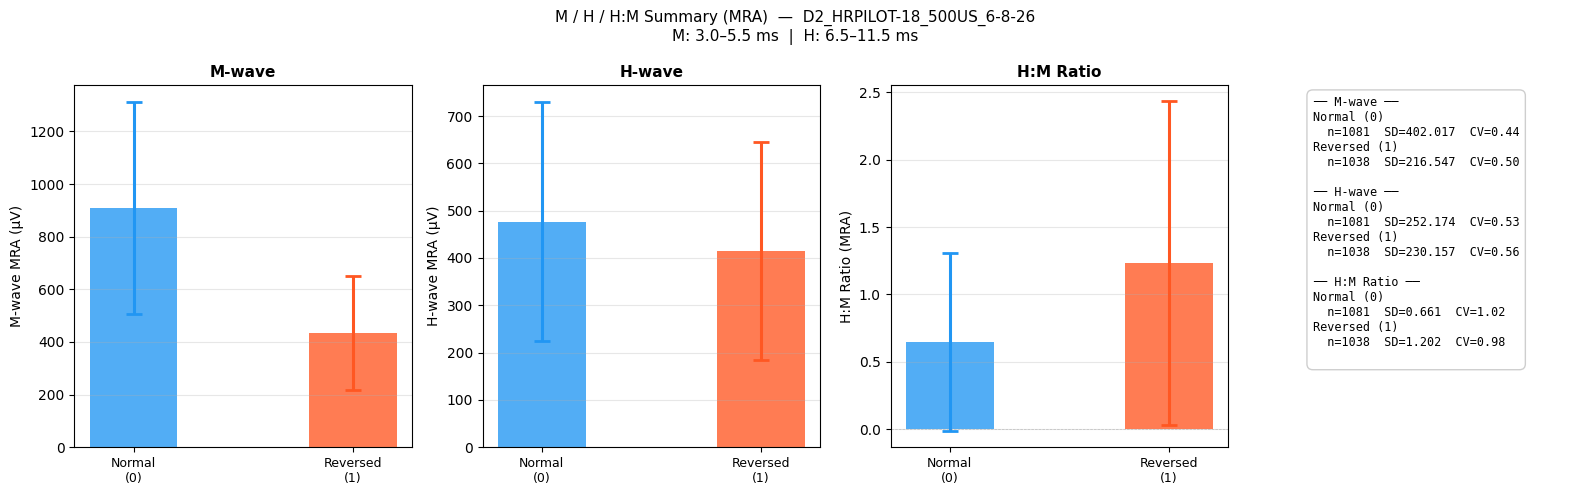

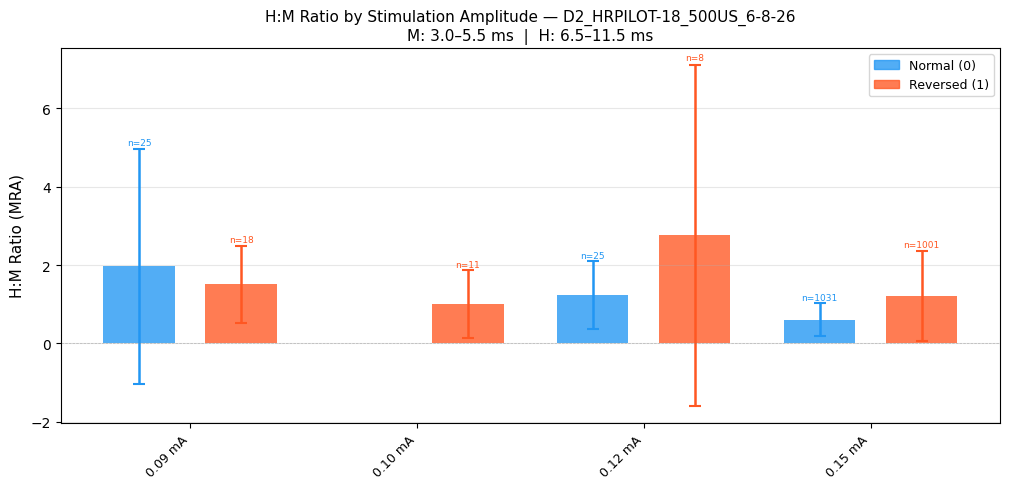

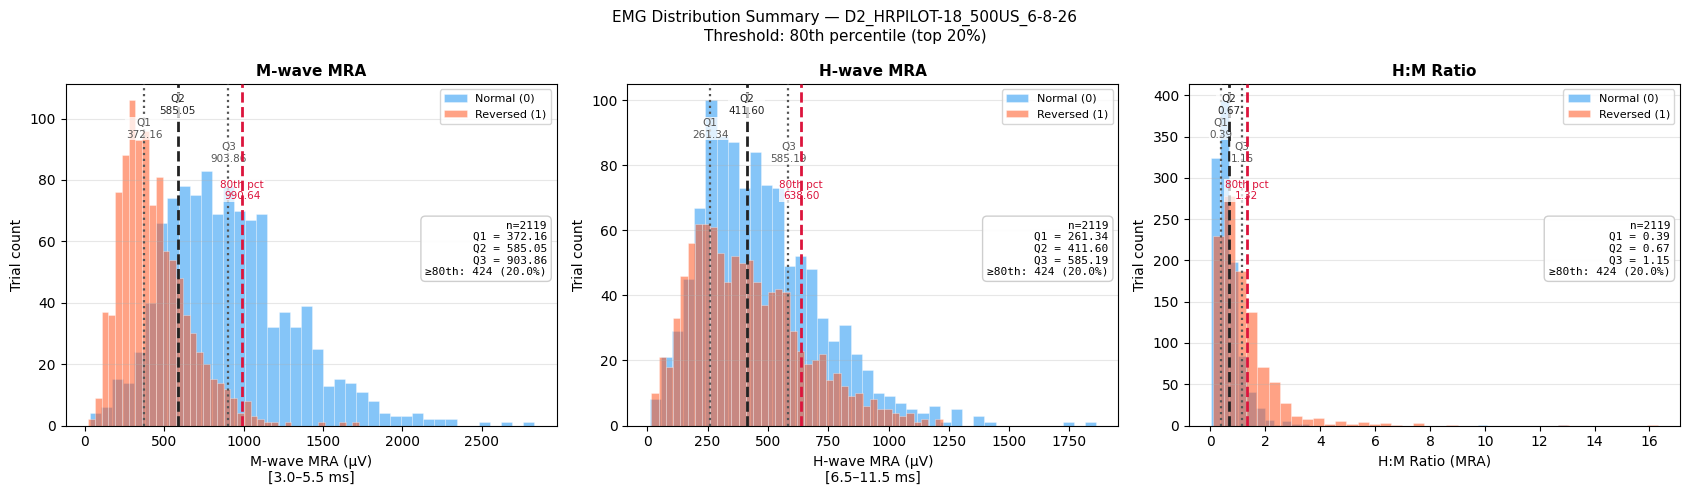

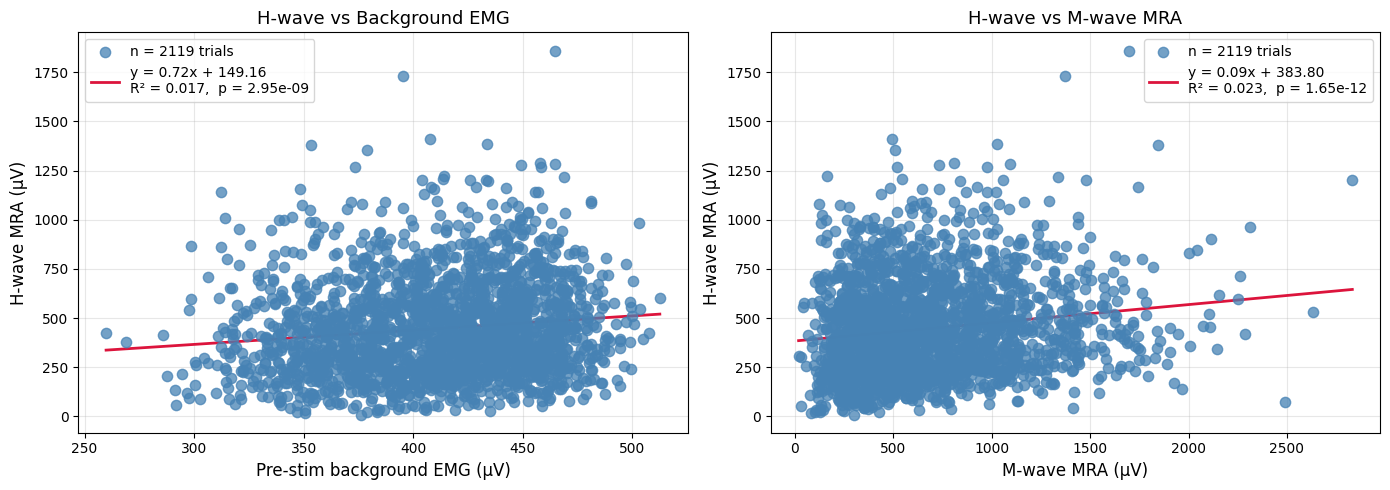

  Regression (n=2119):  slope=0.7242  intercept=149.16  R²=0.0165  p=2.948e-09


In [ ]:
# ---- Stim polarity split ----
trials_by_polarity = split_trials_by_polarity(hrs2_trials)

# ---- H:M Ratio Summary: box plot + histogram ----
# Uses the same M/H windows defined in Section 6a.
plot_hm_ratio_summary(
    trials_by_polarity, hrs2_header,
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)
# ---- H-wave Regression: H-wave amplitude vs background EMG ----
plot_hwave_regression(
    hrs2_trials, hrs2_emg_blocks,
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 7: EMG Window Optimization

## Problem

Choose the best **EMG window** — defined by two decision variables:

| Decision variable | Options |
|---|---|
| **Window Location** (centre) | Q1, Median, or Q3 of the background EMG distribution |
| **Window Size** (EMG window width, ±hw µV) | narrow (±5 µV) → wide (±150 µV) |

## Objectives (simultaneously)

1. **Maximize trial rate** — a wider or better-placed window accepts more trials per session
2. **Minimize M-H variability** — a narrower window selects more uniform background states → more consistent M/H responses

These two objectives **conflict**: larger windows accept more trials but also let in more variable background states.

## Composite score

$$\text{score} = \alpha \times \text{trial\_score} + (1 - \alpha) \times \text{consistency\_score}$$

Both components are independently normalized to **[0, 1]** across all (centre, hw) pairs, so they are directly comparable regardless of units.

| α value | Priority |
|---|---|
| α = 1.0 | Maximize trials only |
| α = 0.5 | Balanced trade-off (default) |
| α = 0.0 | Minimize variability only |

## Pareto front

A (centre, hw) pair is **Pareto-optimal** if no other pair has *both* more trials *and* lower variability — i.e., you cannot improve one objective without hurting the other.
The Pareto front defines the set of efficient operating points.

## Outputs

- **Section 7a**: Compute scores + print ranked table and Pareto solutions
- **Section 7b**: Three-panel visualization:
  1. Pareto scatter — trial count vs variability (Pareto front highlighted)
  2. Composite score heatmap — quick visual of best (centre, hw) combinations
  3. Dual-axis trade-off lines — see exactly how trial count and variability change as you widen the window

In [ ]:
# ---- Section 7a: Compute optimization scores ----
#
# alpha: weight between trial rate and consistency
#   alpha = 1.0  -> maximize accepted trials only
#   alpha = 0.5  -> balanced trade-off (default)
#   alpha = 0.0  -> minimize variability only
#
# VARIABILITY_KEYS: which M-H metrics to include in the variability score
#   options: 'm_mra', 'h_mra', 'hm_ratio', 'm_size', 'h_size'
#
# VARIABILITY_STAT: 'cv' (coefficient of variation, dimensionless) or 'std'

ALPHA            = 0.5
VARIABILITY_KEYS = ['m_mra', 'h_mra']
VARIABILITY_STAT = 'cv'

opt_rows, opt_info = compute_optimization_scores(
    sweep_results, mh_variability,
    variability_keys=VARIABILITY_KEYS,
    variability_stat=VARIABILITY_STAT,
    alpha=ALPHA,
)
print_optimization_summary(opt_rows, opt_info, hrs2_header, top_n=5)


  EMG Window Optimization Summary — D2_HRPILOT-18_500US_6-8-26

  OBJECTIVES
    1. MAXIMIZE  Trial rate (trials/hr)
    2. MINIMIZE  variability  (CV of m_mra, h_mra)

  COMPOSITE SCORE
    score = 0.50 × trial_score + 0.50 × consistency_score
    (each component normalized to [0, 1] across all (centre, hw) pairs)
    alpha = 1.0 → maximize trials only
    alpha = 0.0 → minimize variability only
    alpha = 0.5 → balanced trade-off

  NORMALIZATION RANGES
    Trial rate  : [221.7, 1441.1]
    Variability : [0.6402, 0.6950]

  TOP 5 SOLUTIONS  (by composite score)

  Rank    Centre     ±hw      n   Variability   trial_sc   consist_sc   composite  Pareto
  ───────────────────────────────────────────────────────────────────────────────────────
     1        Q1     150    533        0.6829     1.0000       0.2199      0.6099       ★
     2        Q1     125    483        0.6829     0.8891       0.2195      0.5543        
     3    Median     150    455        0.6828     0.8271       0.22

c:\Users\dal866445\Documents\Github\open-ephys-python-tools\src\open_ephys\analysis\helpers.py:5470: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


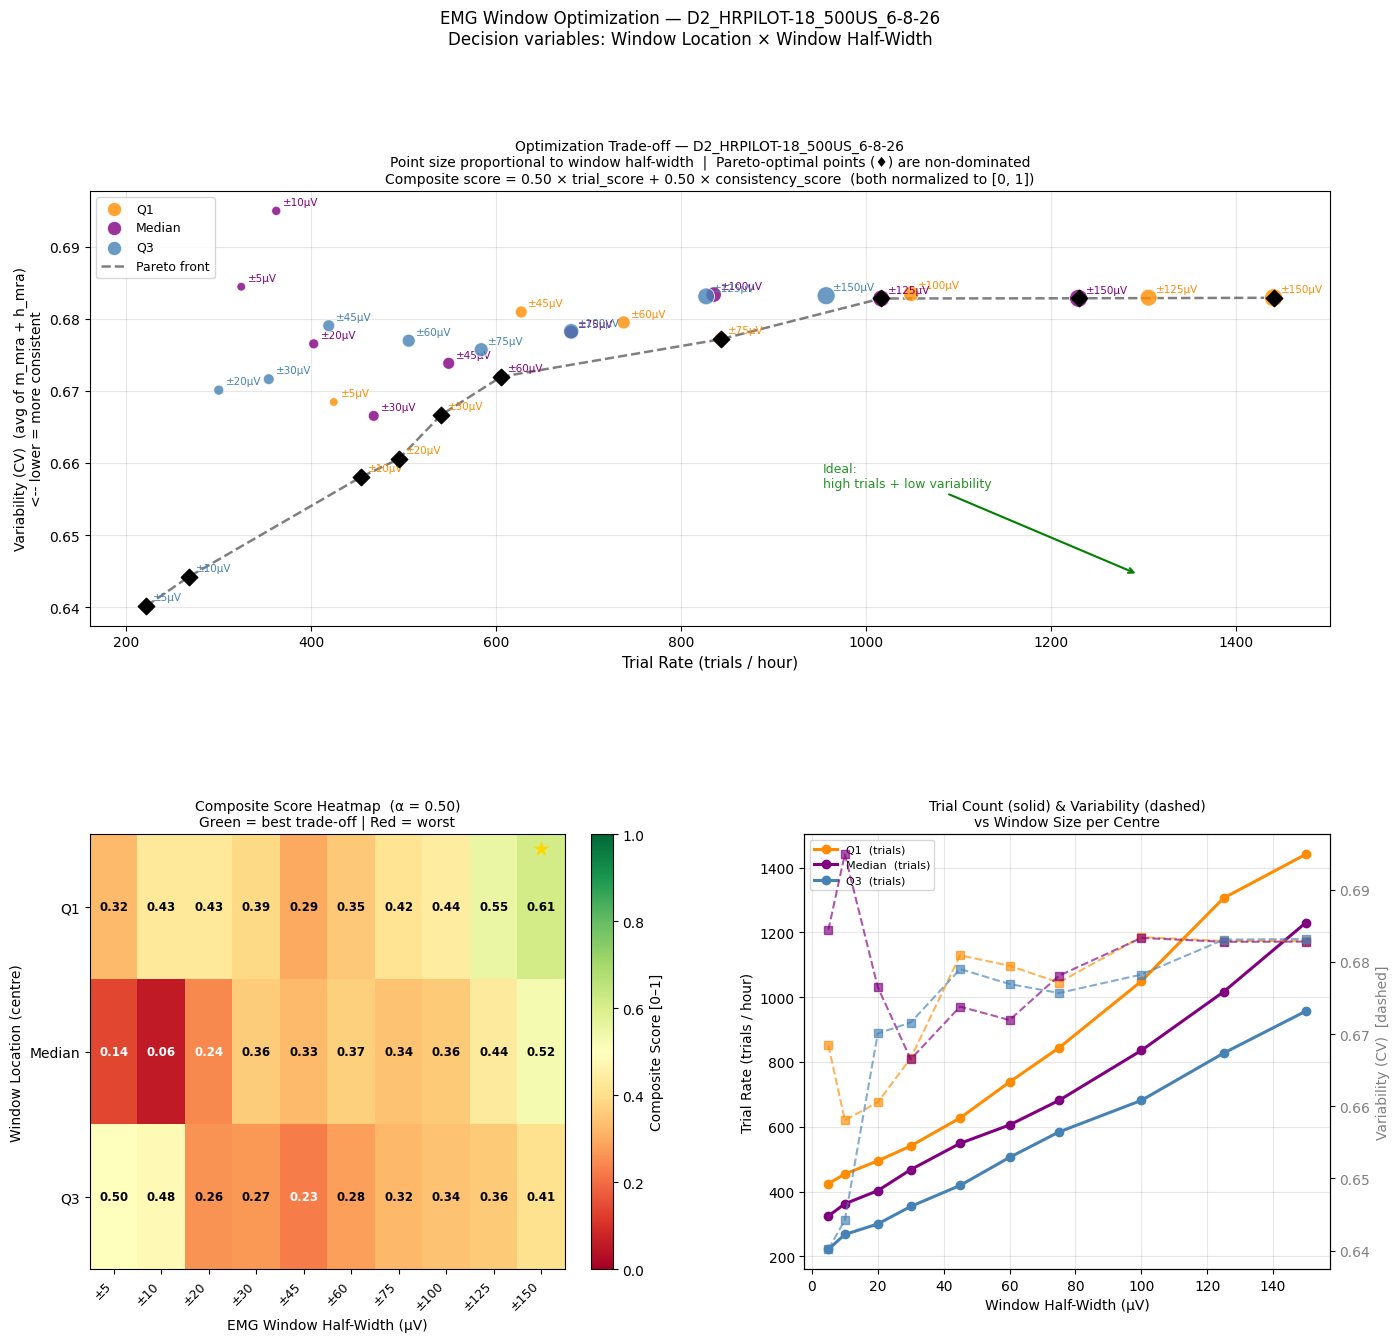

In [ ]:
# ---- Section 7b: Optimization plots ----
# Pareto scatter, composite score heatmap, dual-axis trade-off lines.
# Re-run Section 7a with a different ALPHA to update the heatmap and ranking.S
plot_optimization(opt_rows, opt_info, hrs2_header)